# #30DayMapChallenge - Día 4: Data / Bad Map
## Caso de Negocio: Cuando el GPS miente (y la logística paga la factura)

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
Hoy el reto **no** es hacer un mapa bonito. Es hacer un **mapa malo** a propósito… y luego demostrar por qué la calidad de datos geoespaciales es un KPI operativo.

Imagina una red de *dark stores* / puntos de entrega en CDMX. El equipo de operaciones te entrega un CSV con 500 ubicaciones. Si lo mapeas sin auditoría, verás puntos en el océano, en Tokio y en el Polo Norte. Cualquier ruteo construido sobre eso **rompe costos, ETAs y confianza**.

**Pregunta de negocio:** ¿Qué porcentaje de la red está geográficamente inutilizable y cómo lo recuperamos sin tirar el dataset?

**Reto técnico:** Limpieza de outliers y coordenadas invertidas.

**Fuente de Datos:** Dataset propio (sintético) con errores GPS típicos de captura/ETL (`00_Datos/puntos_entrega_sucios.csv`).

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
from pathlib import Path

plt.style.use('dark_background')
%matplotlib inline

# Rutas relativas al notebook (reproducibles en cualquier máquina)
RUTA_DATOS = Path('../00_Datos/puntos_entrega_sucios.csv')
CARPETA_SALIDA = Path('.')

### 1. Ingesta: el dataset "sucio"
Cargamos las ubicaciones tal como llegarían de un sistema operativo (POS / TMS / app de repartidores). No asumimos calidad.

In [2]:
df = pd.read_csv(RUTA_DATOS)

print(f'Registros cargados: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
display(df.head(10))
print('\nNulos por columna:')
print(df.isna().sum())

Registros cargados: 500
Columnas: ['id_punto', 'alcaldia', 'latitud', 'longitud']


,id_punto,alcaldia,latitud,longitud
0,DS-0001,Azcapotzalco,19.436978,-99.055318
1,DS-0002,Cuauhtémoc,19.269439,-98.995439
2,DS-0003,Coyoacán,NaN,NaN
3,DS-0004,Álvaro Obregón,-99.148547,19.398684
4,DS-0005,Tlalpan,19.097089,-99.141890
5,DS-0006,Miguel Hidalgo,19.537811,-99.030052
6,DS-0007,Álvaro Obregón,19.430570,-99.224220
7,DS-0008,Miguel Hidalgo,19.443032,99.015047
8,DS-0009,Tlalpan,19.114057,-99.152343
9,DS-0010,Gustavo A. Madero,19.275193,-99.303657



Nulos por columna:
id_punto     0
alcaldia     0
latitud     10
longitud    10
dtype: int64


### 2. El Bad Map (antes de limpiar)
Primer principio del día: **visualizar la suciedad**. Si el mapa se ve absurdo, el pipeline de datos también lo es.

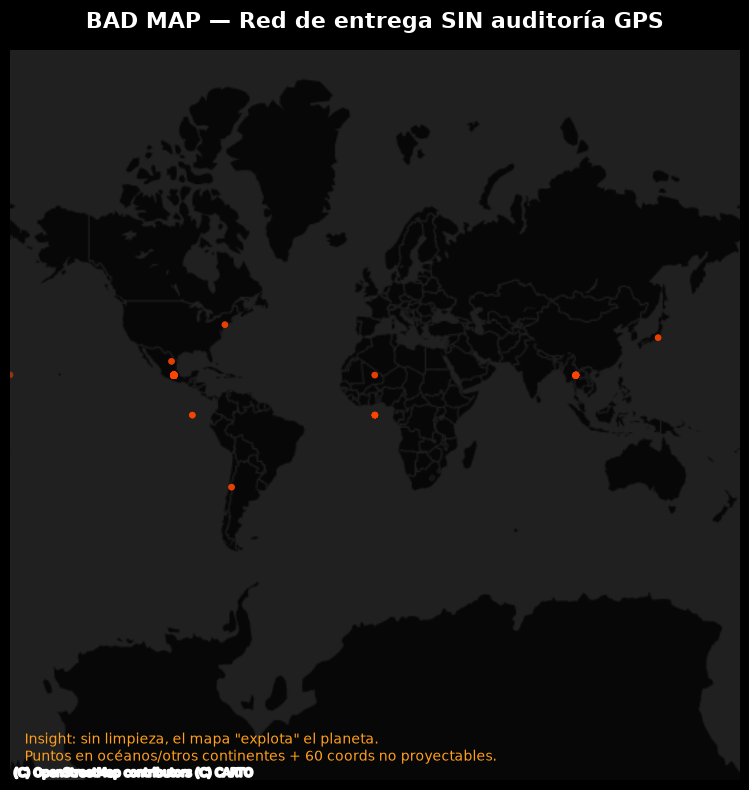

Guardado: Dia4_BadMap_Antes.png


In [3]:
# Para el Bad Map: solo proyectamos puntos dentro del rango WGS84 válido.
# Los tipazos (lat > 90) se cuentan aparte porque rompen Web Mercator.
df_plot = df.dropna(subset=['latitud', 'longitud']).copy()
n_fuera_proyeccion = (
    (~df_plot['latitud'].between(-85, 85)) | (~df_plot['longitud'].between(-180, 180))
).sum()
df_plot = df_plot[
    df_plot['latitud'].between(-85, 85) & df_plot['longitud'].between(-180, 180)
].copy()

gdf_raw = gpd.GeoDataFrame(
    df_plot,
    geometry=gpd.points_from_xy(df_plot['longitud'], df_plot['latitud']),
    crs='EPSG:4326'
)
gdf_raw_web = gdf_raw.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('black')

# Extensión mundial fija para forzar el contraste del "mapa malo"
WORLD = gpd.GeoSeries(
    [gpd.points_from_xy([-180, 180], [-85, 85])[0],
     gpd.points_from_xy([-180, 180], [-85, 85])[1]],
    crs='EPSG:4326'
).to_crs(epsg=3857)
# Bounding box mundial en Web Mercator
ax.set_xlim(-20037508, 20037508)
ax.set_ylim(-20037508, 20037508)

gdf_raw_web.plot(
    ax=ax,
    markersize=22,
    color='#FF4500',
    alpha=0.55,
    edgecolor='none',
    zorder=2
)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.DarkMatterNoLabels,
        zoom=1,
        alpha=0.85,
        zorder=1
    )
except Exception as e:
    print(f'Basemap no disponible ({e}). Continuamos sin tiles.')

ax.set_axis_off()
ax.set_title(
    'BAD MAP — Red de entrega SIN auditoría GPS',
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=16
)
ax.text(
    0.02, 0.02,
    f'Insight: sin limpieza, el mapa "explota" el planeta.\n'
    f'Puntos en océanos/otros continentes + {n_fuera_proyeccion} coords no proyectables.',
    transform=ax.transAxes,
    fontsize=10,
    color='#FF9F1C',
    va='bottom'
)

plt.tight_layout()
plt.savefig(
    CARPETA_SALIDA / 'Dia4_BadMap_Antes.png',
    dpi=180,
    facecolor=fig.get_facecolor(),
    bbox_inches='tight'
)
plt.show()
print('Guardado: Dia4_BadMap_Antes.png')


### 3. Taxonomía de errores GPS
Clasificamos cada registro con reglas de negocio para México / CDMX. Esto convierte "datos malos" en un **diagnóstico accionable**.

In [4]:
# Bounding boxes de referencia
CDMX_LAT = (19.05, 19.55)
CDMX_LON = (-99.35, -98.95)
MX_LAT = (14.5, 32.8)
MX_LON = (-118.5, -86.5)


def clasificar_error(row):
    lat, lon = row['latitud'], row['longitud']

    if pd.isna(lat) or pd.isna(lon):
        return 'nulos'
    if lat == 0 and lon == 0:
        return 'ceros'
    # Lat/lon intercambiados: lat parece longitud mexicana y lon parece latitud CDMX
    if (MX_LON[0] <= lat <= MX_LON[1]) and (MX_LAT[0] <= lon <= MX_LAT[1]):
        return 'coordenadas_invertidas'
    # Signo perdido: longitud positiva cuando debería ser negativa en México
    if (MX_LAT[0] <= lat <= MX_LAT[1]) and (86.5 <= lon <= 118.5):
        return 'signo_longitud'
    # Tipazo decimal: latitud fuera de rango geográfico válido
    if abs(lat) > 90 or abs(lon) > 180:
        return 'tipazo_decimal'
    # Fuera de CDMX (incluye otros estados / países)
    if not (CDMX_LAT[0] <= lat <= CDMX_LAT[1] and CDMX_LON[0] <= lon <= CDMX_LON[1]):
        return 'outlier_geografico'
    return 'ok'


df['diagnostico'] = df.apply(clasificar_error, axis=1)

resumen = df['diagnostico'].value_counts()
pct_malos = (1 - (resumen.get('ok', 0) / len(df))) * 100

print('=== AUDITORÍA GPS ===')
print(resumen.to_string())
print(f'\nKPI: {pct_malos:.1f}% de la red está geográficamente comprometida.')

=== AUDITORÍA GPS ===
diagnostico
ok                        375
coordenadas_invertidas     40
signo_longitud             25
outlier_geografico         22
tipazo_decimal             18
nulos                      10
ceros                      10

KPI: 25.0% de la red está geográficamente comprometida.


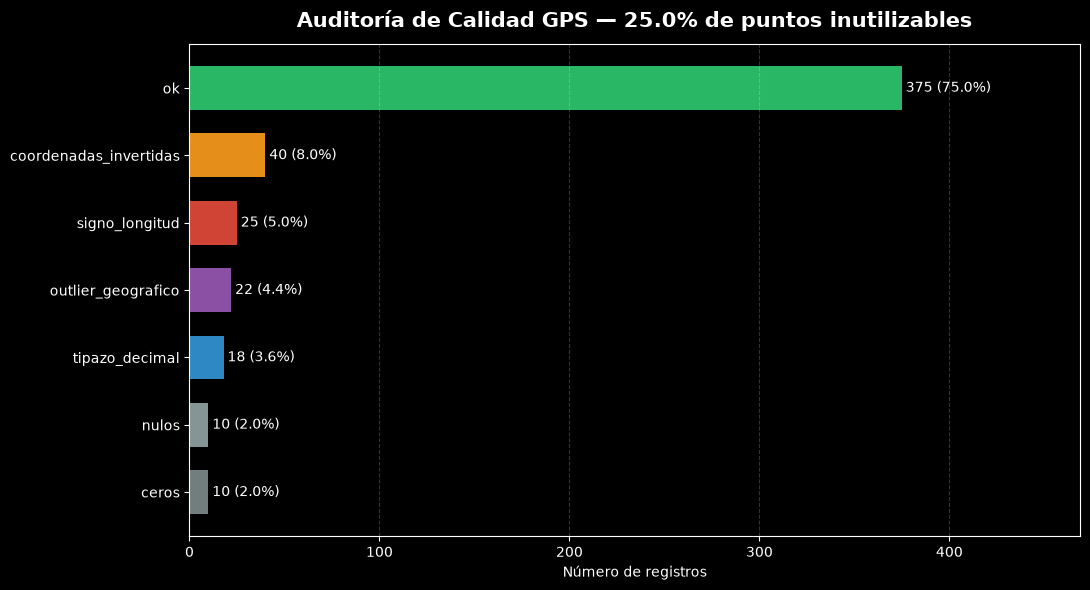

Guardado: Dia4_Auditoria_Errores.png


In [5]:
# Gráfico de auditoría
orden = resumen.sort_values()
colores = {
    'ok': '#2ECC71',
    'coordenadas_invertidas': '#FF9F1C',
    'signo_longitud': '#E74C3C',
    'outlier_geografico': '#9B59B6',
    'tipazo_decimal': '#3498DB',
    'nulos': '#95A5A6',
    'ceros': '#7F8C8D',
}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

bars = ax.barh(
    orden.index,
    orden.values,
    color=[colores.get(k, '#FF4500') for k in orden.index],
    alpha=0.9,
    height=0.65
)

for bar, val in zip(bars, orden.values):
    ax.text(
        val + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{val} ({val / len(df) * 100:.1f}%)',
        va='center',
        color='white',
        fontsize=10
    )

ax.set_title(
    f'Auditoría de Calidad GPS — {pct_malos:.1f}% de puntos inutilizables',
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=12
)
ax.set_xlabel('Número de registros', color='white')
ax.tick_params(colors='white')
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.set_xlim(0, orden.max() * 1.25)

plt.tight_layout()
plt.savefig(
    CARPETA_SALIDA / 'Dia4_Auditoria_Errores.png',
    dpi=180,
    facecolor=fig.get_facecolor(),
    bbox_inches='tight'
)
plt.show()
print('Guardado: Dia4_Auditoria_Errores.png')

### 4. Pipeline de reparación
No tiramos todo: **recuperamos** lo reparable y descartamos lo irrecuperable.

1. Eliminar nulos y ceros.
2. Intercambiar lat/lon cuando detectamos inversión.
3. Corregir signo de longitud en México.
4. Filtrar al bounding box operativo de CDMX.
5. Remover outliers estadísticos residuales (distancia al centroide).

In [6]:
def limpiar_coordenadas(frame: pd.DataFrame):
    '''Aplica reglas de reparación y reporta métricas del pipeline.'''
    stats = {}
    work = frame.copy()
    n0 = len(work)

    # 1) Nulos
    work = work.dropna(subset=['latitud', 'longitud']).copy()
    stats['eliminados_nulos'] = n0 - len(work)

    # 2) Ceros
    n_before = len(work)
    work = work[~((work['latitud'] == 0) & (work['longitud'] == 0))].copy()
    stats['eliminados_ceros'] = n_before - len(work)

    # 3) Coordenadas invertidas -> swap
    mask_swap = (
        work['latitud'].between(MX_LON[0], MX_LON[1])
        & work['longitud'].between(MX_LAT[0], MX_LAT[1])
    )
    stats['reparados_swap'] = int(mask_swap.sum())
    work.loc[mask_swap, ['latitud', 'longitud']] = work.loc[
        mask_swap, ['longitud', 'latitud']
    ].to_numpy()

    # 4) Signo de longitud
    mask_sign = (
        work['latitud'].between(MX_LAT[0], MX_LAT[1])
        & work['longitud'].between(86.5, 118.5)
    )
    stats['reparados_signo'] = int(mask_sign.sum())
    work.loc[mask_sign, 'longitud'] = -work.loc[mask_sign, 'longitud'].abs()

    # 5) Tipazos fuera de rango geográfico
    n_before = len(work)
    work = work[
        work['latitud'].between(-90, 90) & work['longitud'].between(-180, 180)
    ].copy()
    stats['eliminados_tipazo'] = n_before - len(work)

    # 6) Bounding box operativo CDMX
    n_before = len(work)
    work = work[
        work['latitud'].between(*CDMX_LAT) & work['longitud'].between(*CDMX_LON)
    ].copy()
    stats['eliminados_fuera_cdmx'] = n_before - len(work)

    # 7) Outliers residuales por distancia al centroide (metros)
    gdf = gpd.GeoDataFrame(
        work,
        geometry=gpd.points_from_xy(work['longitud'], work['latitud']),
        crs='EPSG:4326'
    ).to_crs(epsg=6362)  # proyección métrica México

    centroide = gdf.geometry.union_all().centroid
    dist_km = gdf.geometry.distance(centroide) / 1000
    umbral = dist_km.quantile(0.99)  # conserva el 99% más compacto
    mask_ok = dist_km <= umbral
    stats['eliminados_outlier_estadistico'] = int((~mask_ok).sum())
    gdf = gdf[mask_ok].copy()

    stats['total_final'] = len(gdf)
    stats['tasa_recuperacion'] = len(gdf) / n0 * 100
    return gdf.to_crs(epsg=4326), stats


gdf_clean, stats = limpiar_coordenadas(df)

print('=== PIPELINE DE REPARACIÓN ===')
for k, v in stats.items():
    if k == 'tasa_recuperacion':
        print(f'{k}: {v:.1f}%')
    else:
        print(f'{k}: {v}')

=== PIPELINE DE REPARACIÓN ===
eliminados_nulos: 10
eliminados_ceros: 10
reparados_swap: 40
reparados_signo: 25
eliminados_tipazo: 18
eliminados_fuera_cdmx: 22
eliminados_outlier_estadistico: 5
total_final: 435
tasa_recuperacion: 87.0%


### 5. Mapa limpio (después)
Con la red reparada, el mapa vuelve a ser una herramienta de decisión: cobertura real de dark stores en CDMX.

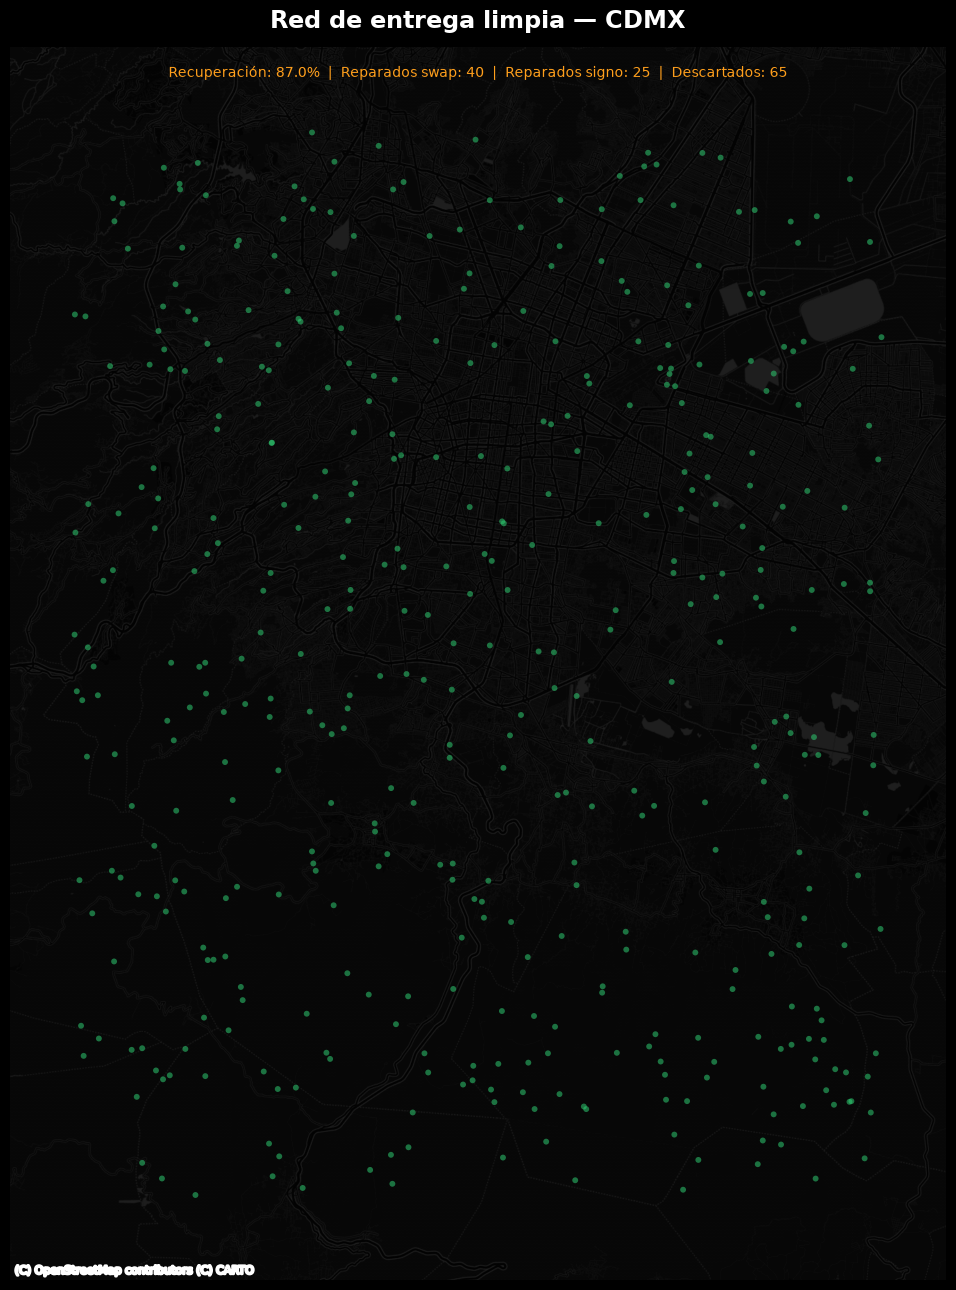

Guardado: Dia4_Mapa_Limpio.png


In [7]:
gdf_clean_web = gdf_clean.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 13))
fig.patch.set_facecolor('black')

gdf_clean_web.plot(
    ax=ax,
    markersize=18,
    color='#2ECC71',
    alpha=0.55,
    edgecolor='none',
    zorder=2
)

minx, miny, maxx, maxy = gdf_clean_web.total_bounds
margin_x = (maxx - minx) * 0.08
margin_y = (maxy - miny) * 0.08
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.DarkMatterNoLabels,
        zoom_adjust=1,
        alpha=0.8,
        zorder=1
    )
except Exception as e:
    print(f'Basemap no disponible ({e}). Continuamos sin tiles.')

ax.set_axis_off()
ax.set_title(
    'Red de entrega limpia — CDMX',
    fontsize=17,
    fontweight='bold',
    color='white',
    pad=14
)
ax.text(
    0.5, 0.985,
    f"Recuperación: {stats['tasa_recuperacion']:.1f}%  |  "
    f"Reparados swap: {stats['reparados_swap']}  |  "
    f"Reparados signo: {stats['reparados_signo']}  |  "
    f"Descartados: {len(df) - stats['total_final']}",
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=10,
    color='#FF9F1C'
)

plt.tight_layout()
plt.savefig(
    CARPETA_SALIDA / 'Dia4_Mapa_Limpio.png',
    dpi=180,
    facecolor=fig.get_facecolor(),
    bbox_inches='tight'
)
plt.show()
print('Guardado: Dia4_Mapa_Limpio.png')

### 6. Antes vs Después (comparativa)
El valor del Data Scientist no es "hacer el mapa". Es **demostrar el delta** entre decidir con datos crudos y decidir con datos auditados.

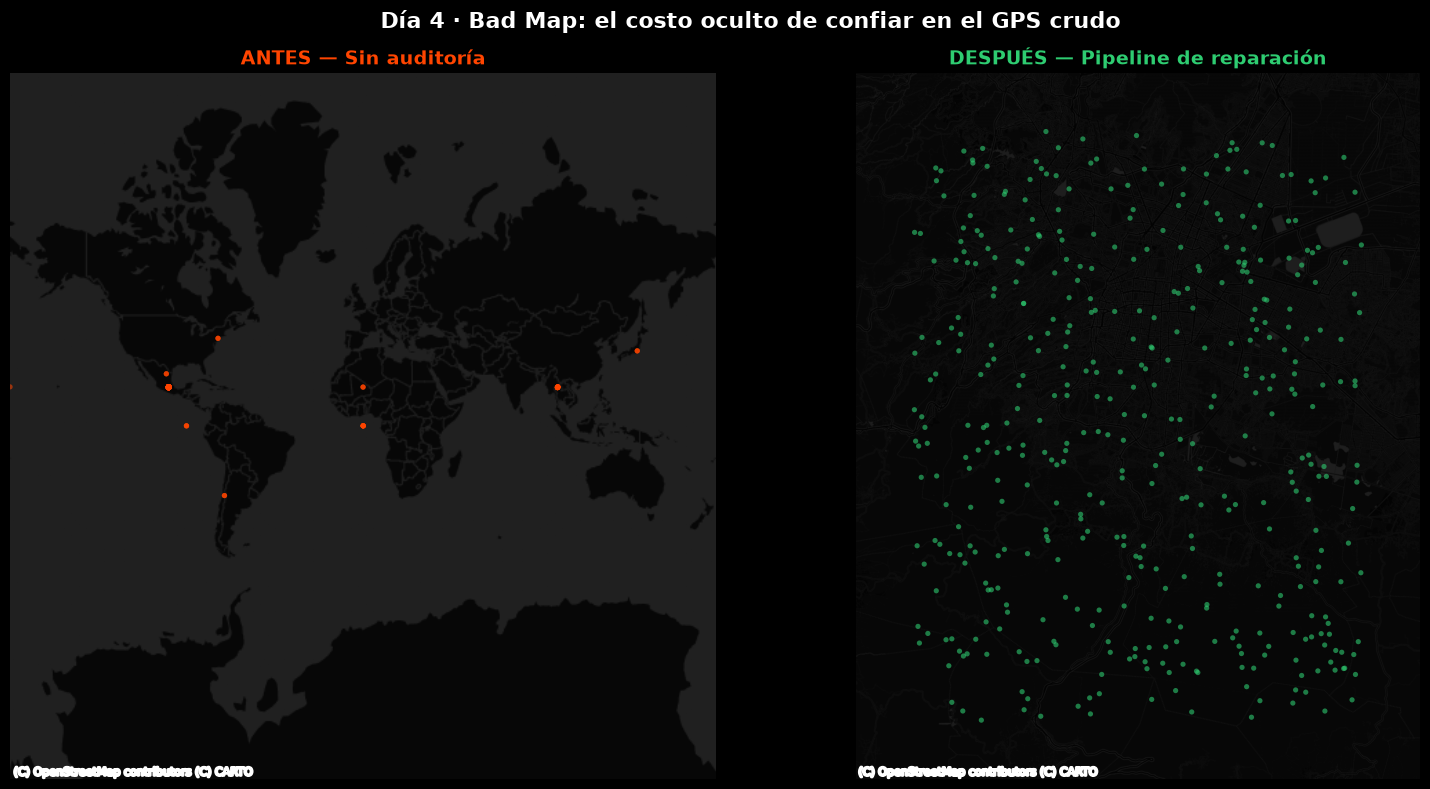

Guardado: Dia4_Antes_vs_Despues.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('black')

# Izquierda: bad map (mundo, extensión fija)
ax0 = axes[0]
ax0.set_xlim(-20037508, 20037508)
ax0.set_ylim(-20037508, 20037508)
gdf_raw_web.plot(ax=ax0, markersize=14, color='#FF4500', alpha=0.55, edgecolor='none', zorder=2)
try:
    ctx.add_basemap(ax0, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom=1, alpha=0.85, zorder=1)
except Exception:
    pass
ax0.set_axis_off()
ax0.set_title('ANTES — Sin auditoría', fontsize=14, fontweight='bold', color='#FF4500')

# Derecha: limpio (CDMX)
ax1 = axes[1]
gdf_clean_web.plot(ax=ax1, markersize=14, color='#2ECC71', alpha=0.6, edgecolor='none', zorder=2)
minx, miny, maxx, maxy = gdf_clean_web.total_bounds
m = max(maxx - minx, maxy - miny) * 0.1
ax1.set_xlim(minx - m, maxx + m)
ax1.set_ylim(miny - m, maxy + m)
try:
    ctx.add_basemap(ax1, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom_adjust=1, alpha=0.8, zorder=1)
except Exception:
    pass
ax1.set_axis_off()
ax1.set_title('DESPUÉS — Pipeline de reparación', fontsize=14, fontweight='bold', color='#2ECC71')

fig.suptitle(
    'Día 4 · Bad Map: el costo oculto de confiar en el GPS crudo',
    fontsize=16,
    fontweight='bold',
    color='white',
    y=0.98
)

plt.tight_layout()
plt.savefig(
    CARPETA_SALIDA / 'Dia4_Antes_vs_Despues.png',
    dpi=180,
    facecolor=fig.get_facecolor(),
    bbox_inches='tight'
)
plt.show()
print('Guardado: Dia4_Antes_vs_Despues.png')


### 7. Insight de negocio
Un mapa "malo" no es solo un fallo estético: es una **fuga operativa**.

- Si ruteas sobre coordenadas invertidas, mandas unidades al lado opuesto de la ciudad.
- Si no filtras outliers, el ETA promedio se vuelve basura estadística.
- Si no auditas el GPS, el dashboard de cobertura miente.

**Regla práctica:** todo dataset con lat/lon necesita un gate de calidad antes de alimentar mapas, modelos o sistemas de ruteo.

### Cómo regenerar los datos
```bash
python ../00_Datos/generarDatosSucios.py
```

In [9]:
# Exportamos la versión limpia para usos posteriores
salida_csv = Path('../00_Datos/puntos_entrega_limpios.csv')
gdf_clean.drop(columns='geometry').to_csv(salida_csv, index=False, encoding='utf-8')
print(f'Dataset limpio exportado: {salida_csv}')
print(f'Puntos finales: {len(gdf_clean):,}')

Dataset limpio exportado: ../00_Datos/puntos_entrega_limpios.csv
Puntos finales: 435
